In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/ev_pare"

In [ ]:
#path = "/content/drive/MyDrive/ev_images/ev_pare/"

##Import Dataset

In [ ]:
import os
import cv2

def loadimages(folder):
  images = []
  for filename in os.listdir(folder):
    img = cv2.imread(os.path.join(folder,filename))
    if img is not None:
      images.append(img)
  return images

In [ ]:
#class0 = loadimages("/content/drive/MyDrive/ev_images/ev_pare/01_crop_training/class0_artifact")
#class1 = loadimages("/content/drive/MyDrive/ev_images/ev_pare/01_crop_training/class1_evegg")


class0 = loadimages("/content/drive/MyDrive/ev_pare/01_crop_training/class0_artifact")
class1 = loadimages("/content/drive/MyDrive/ev_pare/01_crop_training/class1_evegg")

In [ ]:
print(f"class0 shape: {class0[0].shape}")
print(f"class1 shape: {class1[0].shape}")

class0 shape: (500, 500, 3)
class1 shape: (500, 500, 3)


In [ ]:
print(f"num class0: {len(class0)}")
print(f"num class1: {len(class1)}")

num class0: 1415
num class1: 1415


In [ ]:
class0_label = [0] * len(class0)
class1_label = [1] * len(class1)

In [ ]:
from sklearn.model_selection import train_test_split

x_train_class0, x_test_class0, y_train_class0, y_test_class0 = train_test_split(class0, class0_label, test_size=0.2, random_state=8)
x_train_class1, x_test_class1, y_train_class1, y_test_class1 = train_test_split(class1, class1_label, test_size=0.2, random_state=8)

In [ ]:
x_train=[]

for i in x_train_class0:
  x_train.append(i)
for i in x_train_class1:
  x_train.append(i)

In [ ]:
x_test=[]

for i in x_test_class0:
  x_test.append(i)
for i in x_test_class1:
  x_test.append(i)

In [ ]:
y_train=[]

for i in y_train_class0:
  y_train.append(i)
for i in y_train_class1:
  y_train.append(i)

In [ ]:
y_test=[]

for i in y_test_class0:
  y_test.append(i)
for i in y_test_class1:
  y_test.append(i)

In [ ]:
print(f"num x_train: {len(x_train)}")
print(f"num x_test: {len(x_test)}")
print(f"num y_train: {len(y_train)}")
print(f"num y_test: {len(y_test)}")

num x_train: 2264
num x_test: 566
num y_train: 2264
num y_test: 566


##Data Augmentation

In [ ]:
def imrotation(img,angle):
  (h, w) = img.shape[:2]
  center = (w // 2, h // 2)
  matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
  rotate_img = cv2.warpAffine(img, matrix, (w, h))
  return rotate_img[:,:,0:3]

In [ ]:
import numpy as np

def brightness(img, value):
  bright_matrix = np.ones(img.shape, dtype=img.dtype) * value
  brightened_image = cv2.add(img, bright_matrix)
  return brightened_image

In [ ]:
def histeq(img):
  image_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
  image_yuv[:,:,0] = cv2.equalizeHist(image_yuv[:,:,0])
  image = cv2.cvtColor(image_yuv, cv2.COLOR_YUV2BGR)
  return image

In [ ]:
def averaging(img):
  image = cv2.blur(img,(5,5))
  return image

In [ ]:
def addgaussian(img):
  b, g, r = cv2.split(img)

  mean = 0
  sd = 1

  b_noise = np.random.normal(mean, sd, b.shape).astype(np.uint8)
  g_noise = np.random.normal(mean, sd, g.shape).astype(np.uint8)
  r_noise = np.random.normal(mean, sd, r.shape).astype(np.uint8)

  b = cv2.add(b, b_noise)
  g = cv2.add(g, g_noise)
  r = cv2.add(r, r_noise)

  image = cv2.merge([b, g, r])
  return image

In [ ]:
def sharpening(img):
  kernel = np.array([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]])
  image = cv2.filter2D(img, -1, kernel)
  return image

In [ ]:
x_train_temp = []
y_train_temp = []

for i in range(len(x_train)):
  for j in range(0,360,90):
    image_r = imrotation(x_train[i],j)

    x_train_temp.append(image_r)
    y_train_temp.append(y_train[i])

    x_train_temp.append(brightness(image_r, 50))
    y_train_temp.append(y_train[i])

    x_train_temp.append(histeq(image_r))
    y_train_temp.append(y_train[i])

    x_train_temp.append(averaging(image_r))
    y_train_temp.append(y_train[i])

    x_train_temp.append(addgaussian(image_r))
    y_train_temp.append(y_train[i])

    x_train_temp.append(sharpening(image_r))
    y_train_temp.append(y_train[i])

x_train = x_train_temp
y_train = y_train_temp

In [ ]:
print(f"num x_train: {len(x_train)}")
print(f"num y_train: {len(y_train)}")

num x_train: 54336
num y_train: 54336


##Model Training and Validation

In [ ]:
from keras.utils import to_categorical

y_train_cat = to_categorical(y_train)

In [ ]:
for i in range(len(x_train)):
  x_train[i] = cv2.resize(x_train[i], (64,64), interpolation = cv2.INTER_AREA)

for i in range(len(x_test)):
  x_test[i] = cv2.resize(x_test[i], (64,64), interpolation = cv2.INTER_AREA)

In [ ]:
import numpy as np

x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=8)

In [ ]:
set_epoch = 100

Convolutional Neural Networks

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def cnn():
  model = Sequential()
  model = Sequential()

  model.add(Conv2D(32, (3, 3), activation = 'relu', input_shape = (x_train[0].shape)))
  model.add(Conv2D(32, (3, 3), activation = 'relu'))
  model.add(Conv2D(32, (3, 3), activation = 'relu'))
  model.add(MaxPooling2D((2, 2)))
  model.add(Conv2D(16, (3, 3), activation = 'relu'))
  model.add(Conv2D(16, (3, 3), activation = 'relu'))
  model.add(Conv2D(16, (3, 3), activation = 'relu'))
  model.add(MaxPooling2D((2, 2)))
  model.add(Conv2D(8, (3, 3), activation = 'relu'))
  model.add(Conv2D(8, (3, 3), activation = 'relu'))
  model.add(Conv2D(8, (3, 3), activation = 'relu'))
  model.add(MaxPooling2D((2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation = 'relu'))
  model.add(Dense(128, activation = 'relu'))
  model.add(Dense(64, activation = 'relu'))
  model.add(Dense(32, activation = 'relu'))
  model.add(Dense(2, activation = 'sigmoid'))

  model.compile(optimizer = 'sgd', loss = 'mse', metrics = ['accuracy'])
  return model

Resnet50

In [ ]:
from keras.applications import ResNet50

def resnet50():
  model = ResNet50(weights=None, include_top=True, input_shape = x_train[0].shape, classes=2)

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

Mobilenet

In [ ]:
from keras.applications.mobilenet import MobileNet

def Mobilenet():
  model = MobileNet(input_shape = x_train[0].shape, include_top = True, weights = None, classes = 2)

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

DenseNet121

In [ ]:
from keras.applications import DenseNet121

def DenseNet121():
  model = DenseNet121(weights=None, include_top=True, input_shape=x_train[0].shape, classes=2)

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [ ]:
from keras.callbacks import Callback

class earlystopping_manual(Callback):
  def __init__(self, monitor='loss', value=0.001, verbose=1):
    super(Callback, self).__init__()
    self.monitor = monitor
    self.value = value
    self.verbose = verbose

  def on_epoch_end(self, epoch, logs={}):
    current = logs.get(self.monitor)
    if current < self.value:
      self.model.stop_training = True

# CNN cross-val

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.7015 - loss: 0.1922 - val_accuracy: 0.8485 - val_loss: 0.1081
Epoch 2/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8958 - loss: 0.0783 - val_accuracy: 0.8913 - val_loss: 0.0790
Epoch 3/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9329 - loss: 0.0511 - val_accuracy: 0.9134 - val_loss: 0.0658
Epoch 4/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9478 - loss: 0.0399 - val_accuracy: 0.9543 - val_loss: 0.0351
Epoch 5/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9572 - loss: 0.0329 - val_accuracy: 0.9568 - val_loss: 0.0333
Epoch 6/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9644 - loss: 0.0277 - val_accuracy: 0.9568 - val_loss: 0.0333
Epoch 7/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9672 - loss: 0.0253 - val_accuracy: 0.9421 - val_loss: 0.0452
Epoch 8/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9727 - loss:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6322 - loss: 0.2149 - val_accuracy: 0.6977 - val_loss: 0.2113
Epoch 2/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8877 - loss: 0.0862 - val_accuracy: 0.9345 - val_loss: 0.0518
Epoch 3/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9307 - loss: 0.0548 - val_accuracy: 0.9201 - val_loss: 0.0637
Epoch 4/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9517 - loss: 0.0379 - val_accuracy: 0.9576 - val_loss: 0.0330
Epoch 5/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9621 - loss: 0.0300 - val_accuracy: 0.9647 - val_loss: 0.0276
Epoch 6/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9694 - loss: 0.0247 - val_accuracy: 0.9532 - val_loss: 0.0374
Epoch 7/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9741 - loss: 0.0211 - val_accuracy: 0.9745 - val_loss: 0.0211
Epoch 8/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9772 - loss:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7380 - loss: 0.1725 - val_accuracy: 0.8903 - val_loss: 0.0840
Epoch 2/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8970 - loss: 0.0787 - val_accuracy: 0.9127 - val_loss: 0.0648
Epoch 3/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9295 - loss: 0.0546 - val_accuracy: 0.9251 - val_loss: 0.0553
Epoch 4/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9470 - loss: 0.0416 - val_accuracy: 0.9583 - val_loss: 0.0314
Epoch 5/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9563 - loss: 0.0340 - val_accuracy: 0.9610 - val_loss: 0.0308
Epoch 6/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9654 - loss: 0.0272 - val_accuracy: 0.9483 - val_loss: 0.0391
Epoch 7/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9697 - loss: 0.0237 - val_accuracy: 0.9024 - val_loss: 0.0770
Epoch 8/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9744 - loss: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5769 - loss: 0.2492 - val_accuracy: 0.6687 - val_loss: 0.2451
Epoch 2/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7032 - loss: 0.2078 - val_accuracy: 0.6601 - val_loss: 0.2280
Epoch 3/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8592 - loss: 0.1027 - val_accuracy: 0.8940 - val_loss: 0.0756
Epoch 4/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9212 - loss: 0.0597 - val_accuracy: 0.9322 - val_loss: 0.0531
Epoch 5/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9425 - loss: 0.0448 - val_accuracy: 0.9531 - val_loss: 0.0362
Epoch 6/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9519 - loss: 0.0375 - val_accuracy: 0.9581 - val_loss: 0.0325
Epoch 7/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9595 - loss: 0.0317 - val_accuracy: 0.9545 - val_loss: 0.0348
Epoch 8/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9634 - loss: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.6616 - loss: 0.2080 - val_accuracy: 0.7939 - val_loss: 0.1512
Epoch 2/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8804 - loss: 0.0925 - val_accuracy: 0.8650 - val_loss: 0.1002
Epoch 3/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9248 - loss: 0.0595 - val_accuracy: 0.9320 - val_loss: 0.0516
Epoch 4/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9410 - loss: 0.0465 - val_accuracy: 0.9527 - val_loss: 0.0376
Epoch 5/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9520 - loss: 0.0379 - val_accuracy: 0.9504 - val_loss: 0.0404
Epoch 6/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9608 - loss: 0.0312 - val_accuracy: 0.9522 - val_loss: 0.0366
Epoch 7/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9650 - loss: 0.0274 - val_accuracy: 0.9593 - val_loss: 0.0310
Epoch 8/100
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9708 - loss: 

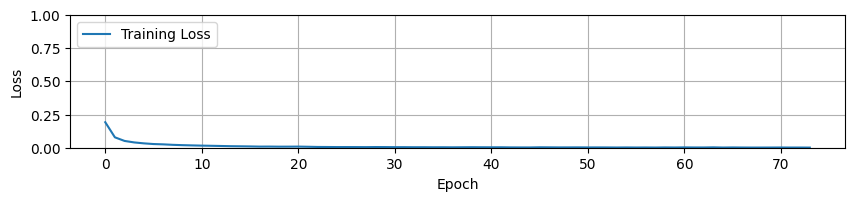

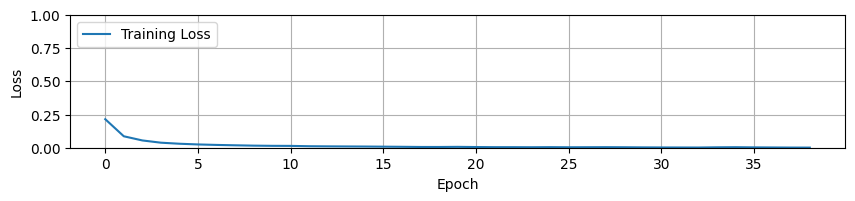

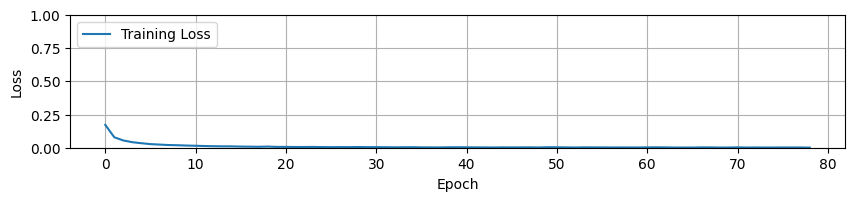

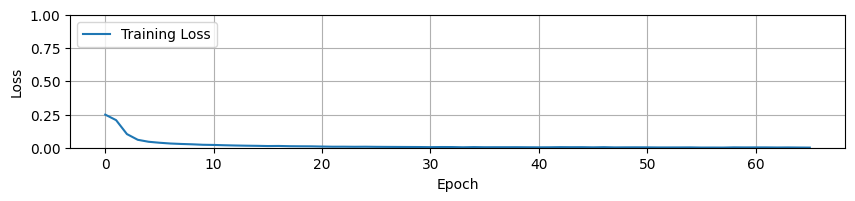

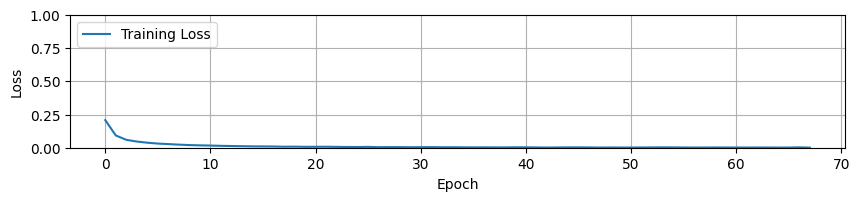

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

fold_acc = []
i = 1

full_x_train = x_train
full_y_train_cat = y_train_cat

for train_ind, test_ind in cv.split(full_x_train):
  x_train_fold = full_x_train[train_ind]
  x_test_fold = full_x_train[test_ind]
  y_train_fold = full_y_train_cat[train_ind]
  y_test_fold = full_y_train_cat[test_ind]

  model = cnn()

  cond = [earlystopping_manual(monitor='loss', value=0.001, verbose=1)]
  history = model.fit(x_train_fold, y_train_fold, epochs = set_epoch, validation_data = (x_test_fold, y_test_fold), callbacks=[cond])

  plt.figure(figsize = (10,10))
  plt.subplot(5,1,i)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.ylim([0, 1])
  plt.legend(loc='upper left')
  plt.grid(True)

  i+=1

  y_pred = model.predict(x_test_fold)
  y_pred = np.argmax(y_pred, axis=1)
  y_true_test_labels = np.argmax(y_test_fold, axis=1)

  print('Confusion Matrix:')
  print(confusion_matrix(y_true_test_labels, y_pred))
  print('--------------------------')
  print("Accuracy:", accuracy_score(y_true_test_labels, y_pred))
  print("Precision:", precision_score(y_true_test_labels, y_pred, average='weighted'))
  print("Recall:", recall_score(y_true_test_labels, y_pred, average='weighted'))
  print("F1 score:", f1_score(y_true_test_labels, y_pred, average='weighted'))

  acc = accuracy_score(y_true_test_labels, y_pred)
  fold_acc.append(acc)

Mean accuracy: 0.99
Standard deviation: 0.00
Individual fold accuracies: [0.9916267942583732, 0.9948467838409865, 0.9949388055581118, 0.9940185883868593, 0.9943866752553603]


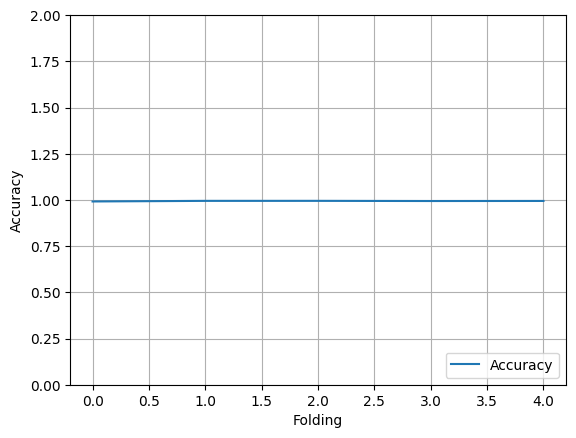

In [ ]:
plt.plot(fold_acc, label='Accuracy')
plt.xlabel('Folding')
plt.ylabel('Accuracy')
plt.ylim([0, 2])
plt.legend(loc='lower right')
plt.grid(True)

print("Mean accuracy: {:.2f}".format(np.mean(fold_acc)))
print("Standard deviation: {:.2f}".format(np.std(fold_acc)))
print("Individual fold accuracies:", fold_acc)

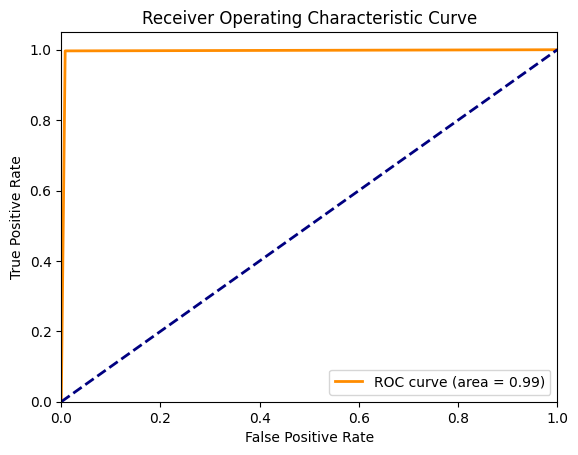

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true_test_labels, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from keras.utils import to_categorical

y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(to_categorical(y_test), axis=1)

print('Confusion Matrix:')
print(confusion_matrix(y_true_labels, y_pred))
print('--------------------------')
print("Accuracy:", accuracy_score(y_true_labels, y_pred))
print("Precision:", precision_score(y_true_labels, y_pred, average='weighted'))
print("Recall:", recall_score(y_true_labels, y_pred, average='weighted'))
print("F1 score:", f1_score(y_true_labels, y_pred, average='weighted'))

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step
Confusion Matrix:
[[276   7]
 [  6 277]]
--------------------------
Accuracy: 0.9770318021201413
Precision: 0.9770377584656877
Recall: 0.9770318021201413
F1 score: 0.9770317304240608


In [ ]:
model.save(path + "ev_cnn_mobile1.keras")
model.save(path + "ev_cnn_mobile1.h5")

#1Convolutional Neural Networks

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3, 3), activation = 'relu', input_shape = (x_train[0].shape)))
model.add(Conv2D(32, (3, 3), activation = 'relu'))
model.add(Conv2D(32, (3, 3), activation = 'relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(16, (3, 3), activation = 'relu'))
model.add(Conv2D(16, (3, 3), activation = 'relu'))
model.add(Conv2D(16, (3, 3), activation = 'relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(8, (3, 3), activation = 'relu'))
model.add(Conv2D(8, (3, 3), activation = 'relu'))
model.add(Conv2D(8, (3, 3), activation = 'relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation = 'relu'))
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(2, activation = 'sigmoid'))

model.compile(optimizer = 'sgd', loss = 'mse', metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(x_train, y_train_cat, epochs = 100, batch_size = 10, validation_split = 0.2)

Epoch 1/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.6249 - loss: 0.2357 - val_accuracy: 0.0000e+00 - val_loss: 0.3726
Epoch 2/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7065 - loss: 0.1963 - val_accuracy: 0.7020 - val_loss: 0.2035
Epoch 3/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8861 - loss: 0.0886 - val_accuracy: 0.9248 - val_loss: 0.0585
Epoch 4/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9400 - loss: 0.0474 - val_accuracy: 0.9132 - val_loss: 0.0671
Epoch 5/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9547 - loss: 0.0357 - val_accuracy: 0.9091 - val_loss: 0.0753
Epoch 6/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9621 - loss: 0.0301 - val_accuracy: 0.9500 - val_loss: 0.0410
Epoch 7/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9714 - loss: 0.0229 - val_accuracy: 0.9825 - val_loss: 0.0140
Epoch 8/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.97

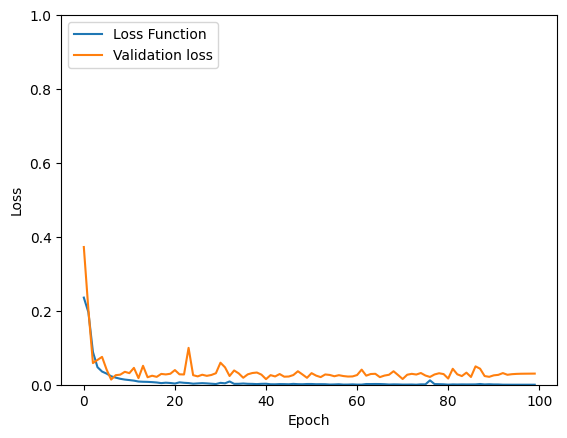

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Loss Function')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='upper left')

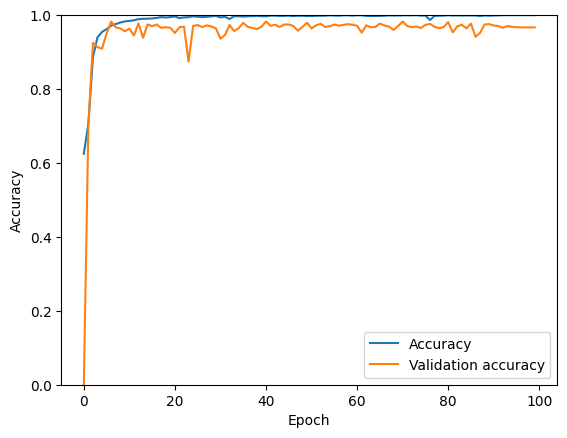

In [ ]:
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [ ]:
y_outp = model.predict(x_test)
y_pred = np.argmax(y_outp, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('--------------------------')
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 score:", f1_score(y_test, y_pred, average='weighted'))

Confusion Matrix:
[[280   3]
 [  6 277]]
--------------------------
Accuracy: 0.9840989399293286
Precision: 0.9841533466533466
Recall: 0.9840989399293286
F1 score: 0.9840984931964403


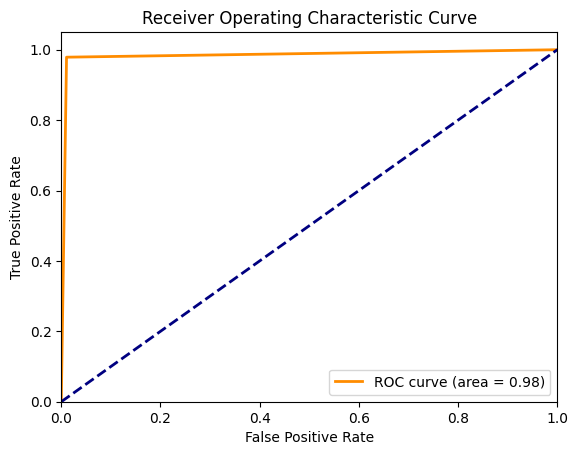

In [ ]:
from sklearn.metrics import roc_curve, auc #ROC

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
model.save(path + "ev_cnn_mobileprae.keras")
model.save(path + "ev_cnn_mobile.h5")

#2Resnet50

In [ ]:
from keras.applications import ResNet50

model = ResNet50(weights=None, include_top=True, input_shape = x_train[0].shape, classes=2)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train_cat, epochs = 100, batch_size = 10, validation_split = 0.2)

Epoch 1/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 160s 24ms/step - accuracy: 0.9156 - loss: 0.2333 - val_accuracy: 0.3289 - val_loss: 1.7304
Epoch 2/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 77s 18ms/step - accuracy: 0.9664 - loss: 0.0983 - val_accuracy: 0.9499 - val_loss: 0.1766
Epoch 3/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 77s 18ms/step - accuracy: 0.9722 - loss: 0.0869 - val_accuracy: 0.6630 - val_loss: 1.0215
Epoch 4/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 77s 18ms/step - accuracy: 0.9889 - loss: 0.0329 - val_accuracy: 0.5206 - val_loss: 0.9230
Epoch 5/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 77s 18ms/step - accuracy: 0.9903 - loss: 0.0312 - val_accuracy: 0.8600 - val_loss: 0.3185
Epoch 6/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 77s 18ms/step - accuracy: 0.9938 - loss: 0.0187 - val_accuracy: 0.8739 - val_loss: 0.3242
Epoch 7/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 77s 18ms/step - accuracy: 0.9950 - loss: 0.0143 - val_accuracy: 0.6732 - val_loss: 1.5574
Epoch 8/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 77s 18ms/step - accuracy:

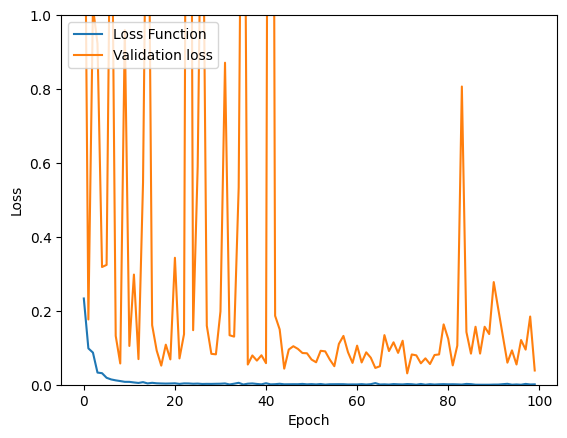

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Loss Function')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='upper left')

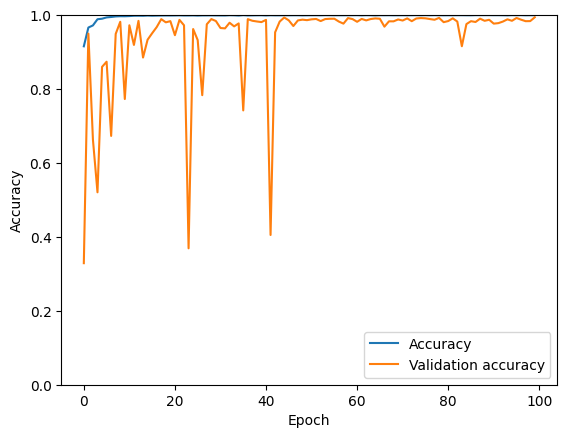

In [ ]:
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [ ]:
y_outp = model.predict(x_test)
y_pred = np.argmax(y_outp, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 354ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('--------------------------')
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 score:", f1_score(y_test, y_pred, average='weighted'))

Confusion Matrix:
[[282   1]
 [  1 282]]
--------------------------
Accuracy: 0.9964664310954063
Precision: 0.9964664310954063
Recall: 0.9964664310954063
F1 score: 0.9964664310954063


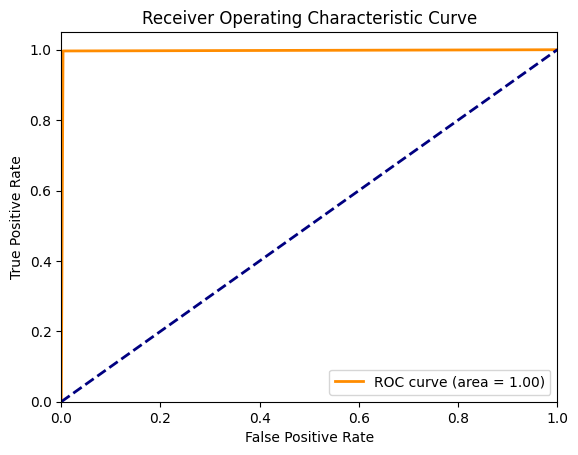

In [ ]:
from sklearn.metrics import roc_curve, auc #ROC

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
model.save(path + "ev_resnet50_mobile.keras")

#3Mobilenet

In [ ]:
from keras.applications.mobilenet import MobileNet

model = MobileNet(input_shape = x_train[0].shape, include_top = True, weights = None, classes = 2)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train_cat, epochs = 100, batch_size = 10, validation_split = 0.2)

Epoch 1/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 102s 14ms/step - accuracy: 0.8792 - loss: 0.2832 - val_accuracy: 0.9466 - val_loss: 0.1851
Epoch 2/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.9720 - loss: 0.0814 - val_accuracy: 0.5663 - val_loss: 1.6409
Epoch 3/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.9849 - loss: 0.0451 - val_accuracy: 0.9579 - val_loss: 0.1364
Epoch 4/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.9903 - loss: 0.0293 - val_accuracy: 0.9820 - val_loss: 0.0577
Epoch 5/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.9929 - loss: 0.0211 - val_accuracy: 0.9795 - val_loss: 0.1153
Epoch 6/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - accuracy: 0.9953 - loss: 0.0164 - val_accuracy: 0.9622 - val_loss: 0.1405
Epoch 7/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.9962 - loss: 0.0131 - val_accuracy: 0.9716 - val_loss: 0.1121
Epoch 8/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.9971

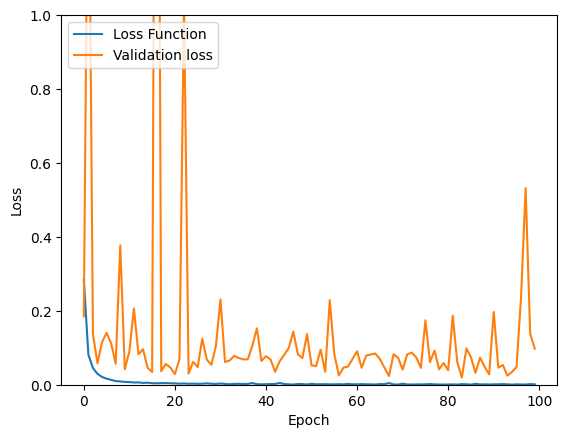

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Loss Function')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='upper left')

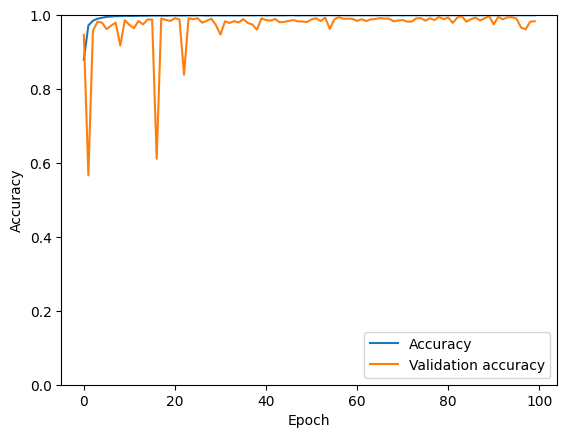

In [ ]:
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [ ]:
y_outp = model.predict(x_test)
y_pred = np.argmax(y_outp, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 611ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('--------------------------')
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 score:", f1_score(y_test, y_pred, average='weighted'))

Confusion Matrix:
[[283   0]
 [  5 278]]
--------------------------
Accuracy: 0.991166077738516
Precision: 0.9913194444444444
Recall: 0.991166077738516
F1 score: 0.9911653883014756


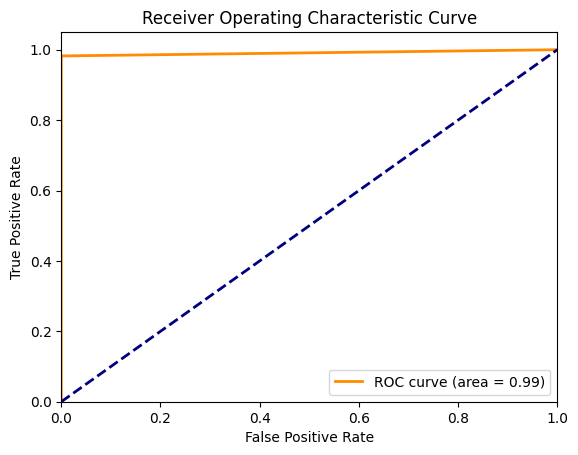

In [ ]:
from sklearn.metrics import roc_curve, auc #ROC

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
model.save(path + "ev_mobilenet_mobileprae.keras")

#4DenseNet121

In [ ]:
from keras.applications import DenseNet121

model = DenseNet121(weights=None, include_top=True, input_shape=x_train[0].shape, classes=2)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train_cat, epochs = 100, batch_size = 10, validation_split = 0.2)

Epoch 1/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 391s 57ms/step - accuracy: 0.9102 - loss: 0.2152 - val_accuracy: 0.5431 - val_loss: 1.3691
Epoch 2/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 149s 34ms/step - accuracy: 0.9819 - loss: 0.0529 - val_accuracy: 0.9649 - val_loss: 0.0870
Epoch 3/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 148s 34ms/step - accuracy: 0.9903 - loss: 0.0301 - val_accuracy: 0.6563 - val_loss: 1.2615
Epoch 4/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 150s 35ms/step - accuracy: 0.9933 - loss: 0.0204 - val_accuracy: 0.8003 - val_loss: 0.7145
Epoch 5/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 147s 34ms/step - accuracy: 0.9946 - loss: 0.0164 - val_accuracy: 0.8532 - val_loss: 0.5991
Epoch 6/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 149s 34ms/step - accuracy: 0.9961 - loss: 0.0126 - val_accuracy: 0.6394 - val_loss: 1.6600
Epoch 7/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 147s 34ms/step - accuracy: 0.9968 - loss: 0.0090 - val_accuracy: 0.9770 - val_loss: 0.0774
Epoch 8/100
4347/4347 ━━━━━━━━━━━━━━━━━━━━ 150s 34ms/step - ac

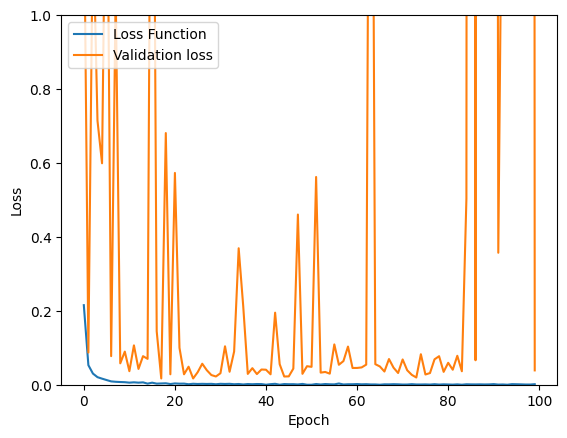

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Loss Function')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='upper left')

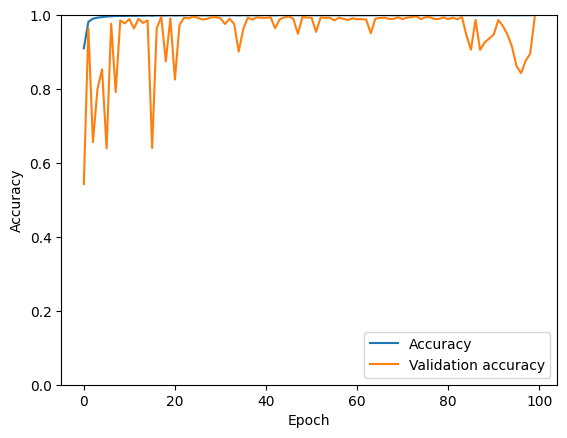

In [ ]:
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [ ]:
y_outp = model.predict(x_test)
y_pred = np.argmax(y_outp, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 923ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('--------------------------')
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 score:", f1_score(y_test, y_pred, average='weighted'))

Confusion Matrix:
[[282   1]
 [  4 279]]
--------------------------
Accuracy: 0.991166077738516
Precision: 0.9912212787212786
Recall: 0.991166077738516
F1 score: 0.9911658295535778


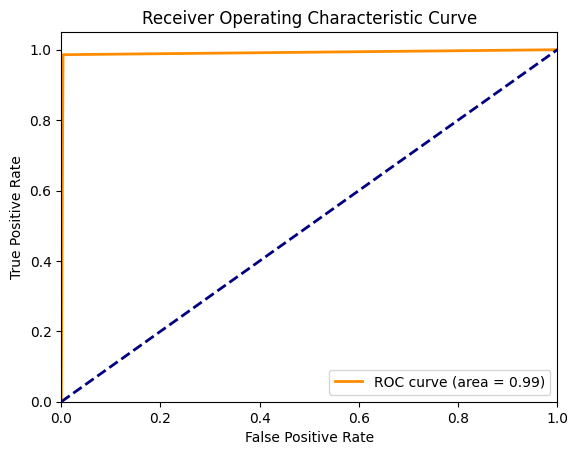

In [ ]:
from sklearn.metrics import roc_curve, auc #ROC

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
model.save(path + "ev_densenet121_mobileprae.keras")